In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [6]:
# load the data
neurons = pd.read_csv('../../../data/BANC/neurons.csv.gz')
connections = pd.read_csv('../../../data/BANC/connections_princeton.csv.gz')

In [ ]:
ORNs = neurons[neurons['Class']=='olfactory_receptor_neuron'].reset_index()
ORNs.head()

,Root ID,Top in/out region,Community labels,Predicted NT type,Predicted NT confidence,Verified NT type,Verified Neuropeptide,Body Part,Function,Flow,...,Class,Sub Class,Hemilineage,Nerve,Soma side,Primary Cell Type,Alternative Cell Type(s),Cable length (nm),Surface area (nm^2),Volume (nm^3)
239,720575941352084784,AL,NaN,ACH,0.99,acetylcholine,NaN,maxillary_palp,"olfactory,yeasty_volatile",afferent,...,olfactory_receptor_neuron,maxillary_palp_olfactory_receptor_neuron,NaN,left_antennal_nerve,left,ORN_VM5v,ORN_VM5v,NaN,NaN,NaN
286,720575941352539440,AL,NaN,ACH,0.99,acetylcholine,NaN,maxillary_palp,"olfactory,yeasty_volatile",afferent,...,olfactory_receptor_neuron,maxillary_palp_olfactory_receptor_neuron,NaN,left_antennal_nerve,left,ORN_VM5v,ORN_VM5v,NaN,NaN,NaN
343,720575941352825904,AL,NaN,ACH,0.99,acetylcholine,sNPF,antenna,"olfactory,yeasty_volatile",afferent,...,olfactory_receptor_neuron,antenna_olfactory_receptor_neuron,NaN,left_antennal_nerve,left,ORN_VA6,ORN_VA6,NaN,NaN,NaN
441,720575941353213744,AL,NaN,ACH,0.97,NaN,NaN,NaN,NaN,afferent,...,olfactory_receptor_neuron,antenna_olfactory_receptor_neuron,NaN,right_antennal_nerve,right,NaN,NaN,NaN,NaN,NaN
484,720575941353462832,AL,NaN,ACH,0.98,acetylcholine,NaN,maxillary_palp,"olfactory,yeasty_volatile",afferent,...,olfactory_receptor_neuron,maxillary_palp_olfactory_receptor_neuron,NaN,left_antennal_nerve,left,ORN_DM5,ORN_DM5,NaN,NaN,NaN


In [39]:
def compute_asymmetry(row):
    root = row['Root ID']
    # Determine if the ORN is left-sided
    is_left = str(row['Soma side']).startswith("left")
    
    # Compute synapse counts in lateral regions AL_R and AL_L
    sub_conn = connections[connections['pre_root_id'] == root]
    temp_counts = sub_conn.groupby('neuropil').sum()['syn_count']
    li_synapse = (temp_counts.get('AL_R', 0) - temp_counts.get('AL_L', 0)) / \
                 (temp_counts.get('AL_R', 0) + temp_counts.get('AL_L', 0) + 1e-9)
    # Flip sign if the neuron is not left-sided
    li_synapse = -li_synapse if is_left else li_synapse

    # Compute unique partners in lateral regions AL_R and AL_L
    temp_partners = sub_conn.groupby('neuropil').nunique()['post_root_id']
    li_partner = (temp_partners.get('AL_R', 0) - temp_partners.get('AL_L', 0)) / \
                 (temp_partners.get('AL_R', 0) + temp_partners.get('AL_L', 0) + 1e-9)
    li_partner = -li_partner if is_left else li_partner
    
    return pd.Series({
        'ORN_type': row['Primary Cell Type'],
        'LI_partner': li_partner,
        'LI_synapse': li_synapse,
        'ORN_side': row['Soma side']
    })

result_df = ORNs.apply(compute_asymmetry, axis=1)
result_df.head()

,ORN_type,LI_partner,LI_synapse,ORN_side
239,ORN_VM5v,-0.411765,-0.213483,left
286,ORN_VM5v,1.000000,1.000000,left
343,ORN_VA6,-0.333333,0.059829,left
441,NaN,1.000000,1.000000,right
484,ORN_DM5,1.000000,1.000000,left


/var/folders/y6/xn2dyw2s14b79mrpmzrhykhc0000gn/T/ipykernel_31365/3009756936.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='ORN_type', y='LI_partner', data=result_df, order=order, fliersize=0, palette='vlag', showcaps=False)


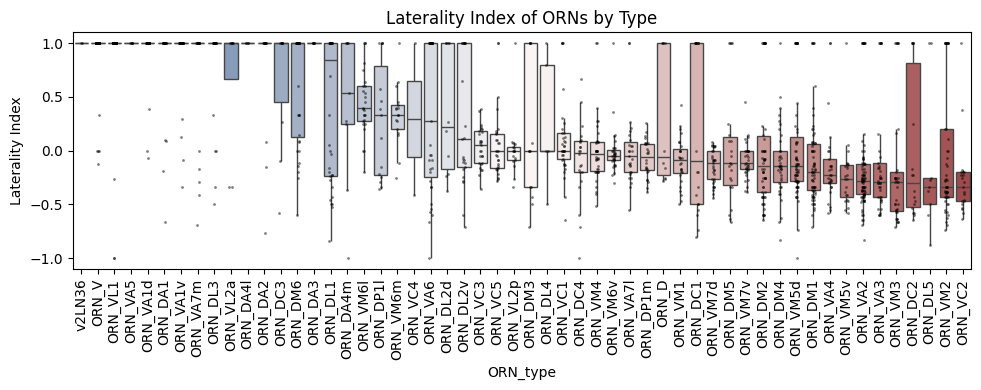

In [40]:
# plot aggregate laterality index by type (sorted by median laterality index)
order = result_df.groupby('ORN_type')['LI_partner'].median().sort_values(ascending=False).index

plt.figure(figsize=(10,4))
sns.boxplot(x='ORN_type', y='LI_partner', data=result_df, order=order, fliersize=0, palette='vlag', showcaps=False)
sns.stripplot(x='ORN_type', y='LI_partner', data=result_df, order=order, color='k', size=2, alpha=0.5, jitter=True)
plt.xticks(rotation=90)
plt.ylabel('Laterality Index')
plt.title('Laterality Index of ORNs by Type')
plt.tight_layout()
plt.show()


In [41]:
result_df.to_csv('banc-ORN-LI.csv', index=False)

In [ ]:
root_id = ORNs.iloc[0]['Root ID']
temp_counts = connections[connections['pre_root_id']==root_id].groupby('neuropil').sum()['syn_count']
orn_side = ORNs.iloc[0]['Soma side'] == 'left'
count_asymmetry = (temp_counts.get('AL_R',0) - temp_counts.get('AL_L',0)) / (temp_counts.get('AL_R',0) + temp_counts.get('AL_L',0) + 1e-9) * (1 if orn_side else -1)
temp_partners = connections[connections['pre_root_id']==root_id].groupby('neuropil').nunique()['post_root_id']
partner_asymmetry = (temp_partners.get('AL_R',0) - temp_partners.get('AL_L',0)) / (temp_partners.get('AL_R',0) + temp_partners.get('AL_L',0) + 1e-9) * (1 if orn_side else -1)
print(ORNs.iloc[0]['Primary Cell Type'], orn_side, count_asymmetry, partner_asymmetry)